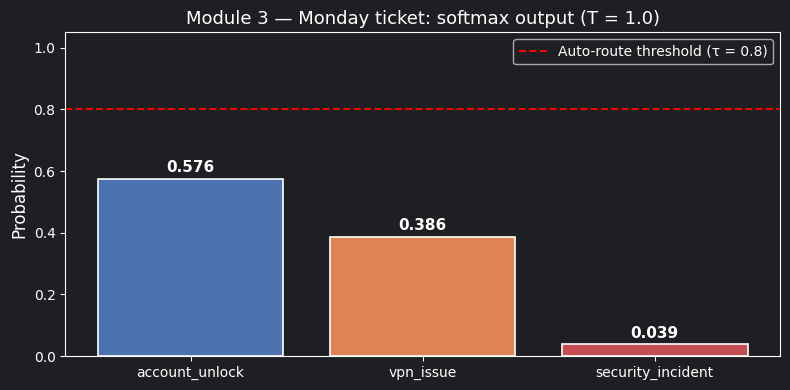

Margin (top-1 minus top-2): 0.190


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Canonical Monday ticket values ──────────────────────────────────────────
logits     = np.array([3.2, 2.8, 0.5])
labels     = ["account_unlock", "vpn_issue", "security_incident"]
colors     = ["#4C72B0", "#DD8452", "#C44E52"]
threshold  = 0.80

def softmax(z, T=1.0):
    z_shifted = z - np.max(z)          # numerically stable
    e = np.exp(z_shifted / T)
    return e / e.sum()

probs = softmax(logits)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, probs, color=colors, edgecolor="white", linewidth=1.2)
ax.axhline(threshold, color="red", linestyle="--", linewidth=1.4,
           label=f"Auto-route threshold (τ = {threshold})")

# Annotate bars
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 0.012,
            f"{p:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.05)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Module 3 — Monday ticket: softmax output (T = 1.0)", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("m3_fig1_default_softmax.png", dpi=150)
plt.show()
print(f"Margin (top-1 minus top-2): {probs[0] - probs[1]:.3f}")
# Expected output:
# account_unlock=0.576, vpn_issue=0.386, security_incident=0.039
# Margin: 0.190

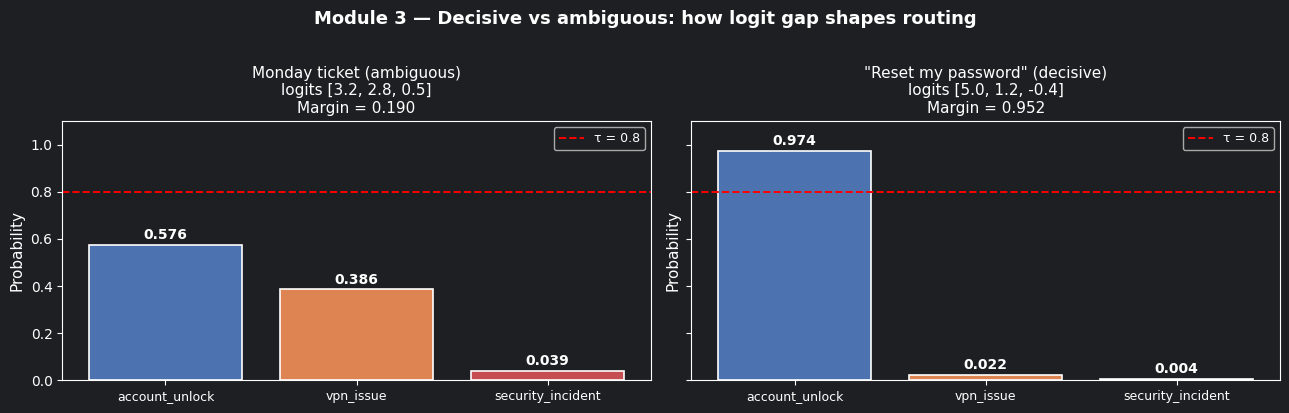

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

ticket_data = [
    {
        "title": "Monday ticket (ambiguous)\nlogits [3.2, 2.8, 0.5]",
        "logits": np.array([3.2, 2.8, 0.5]),
    },
    {
        "title": '"Reset my password" (decisive)\nlogits [5.0, 1.2, -0.4]',
        "logits": np.array([5.0, 1.2, -0.4]),
    },
]

for ax, td in zip(axes, ticket_data):
    p = softmax(td["logits"])
    bars = ax.bar(labels, p, color=colors, edgecolor="white", linewidth=1.2)
    ax.axhline(threshold, color="red", linestyle="--", linewidth=1.4,
               label=f"τ = {threshold}")
    for bar, prob in zip(bars, p):
        ax.text(bar.get_x() + bar.get_width() / 2, prob + 0.012,
                f"{prob:.3f}", ha="center", va="bottom", fontsize=10,
                fontweight="bold")
    margin = p[0] - p[1]
    ax.set_title(f"{td['title']}\nMargin = {margin:.3f}", fontsize=11)
    ax.set_ylim(0, 1.10)
    ax.set_ylabel("Probability", fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", labelsize=9)

fig.suptitle("Module 3 — Decisive vs ambiguous: how logit gap shapes routing",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("m3_fig2_decisive_vs_ambiguous.png", dpi=150)
plt.show()

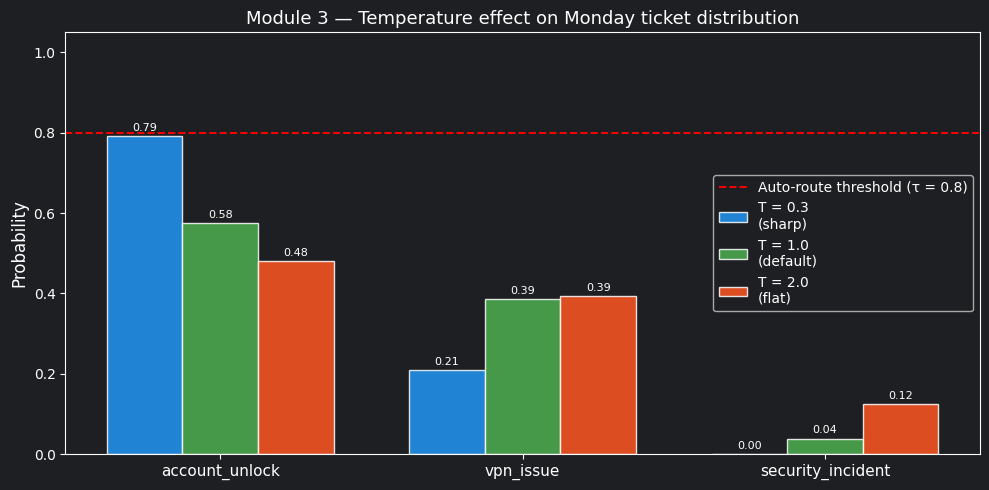

Temp     account_unlock     vpn_issue      security_incident    Margin
------------------------------------------------------------------------
T=0.3    0.791              0.209          0.000                0.583
T=1.0    0.576              0.386          0.039                0.190
T=2.0    0.481              0.394          0.125                0.087


In [8]:
temperatures = [0.3, 1.0, 2.0]
temp_labels  = ["T = 0.3\n(sharp)", "T = 1.0\n(default)", "T = 2.0\n(flat)"]
x = np.arange(len(labels))
width = 0.25
bar_colors = ["#2196F3", "#4CAF50", "#FF5722"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (T, tlabel, bc) in enumerate(zip(temperatures, temp_labels, bar_colors)):
    p = softmax(logits, T=T)
    offset = (i - 1) * width
    bars = ax.bar(x + offset, p, width, label=tlabel, color=bc,
                  alpha=0.85, edgecolor="white")
    for bar, prob in zip(bars, p):
        ax.text(bar.get_x() + bar.get_width() / 2, prob + 0.008,
                f"{prob:.2f}", ha="center", va="bottom", fontsize=8)

ax.axhline(threshold, color="red", linestyle="--", linewidth=1.4,
           label=f"Auto-route threshold (τ = {threshold})")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Module 3 — Temperature effect on Monday ticket distribution",
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("m3_fig3_temperature_effect.png", dpi=150)
plt.show()

# ── Print the table for reference ──
print(f"{'Temp':<8} {'account_unlock':<18} {'vpn_issue':<14} "
      f"{'security_incident':<20} {'Margin'}")
print("-" * 72)
for T in temperatures:
    p = softmax(logits, T=T)
    print(f"T={T:<6} {p[0]:.3f}{'':13} {p[1]:.3f}{'':9} "
          f"{p[2]:.3f}{'':15} {p[0]-p[1]:.3f}")